In [2]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

# Загружаем датасет
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,               
    "uciml/breast-cancer-wisconsin-data",     
    "data.csv"                                
)

# Проверяем
df.head()
df.info()

E:\Projects\Python\MashineLeaning\HomeWork1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Home\AppData\Local\Temp\ipykernel_16912\2638340130.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [3]:
# базовые статистики для всех колонок
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [8]:
# Варианты для целевой переменной diagnosis
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [9]:
# какие колонки имеют пропуски
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [4]:
# эта колонка полностью пустая и мы ее удаляем
df = df.drop(columns=['Unnamed: 32'])

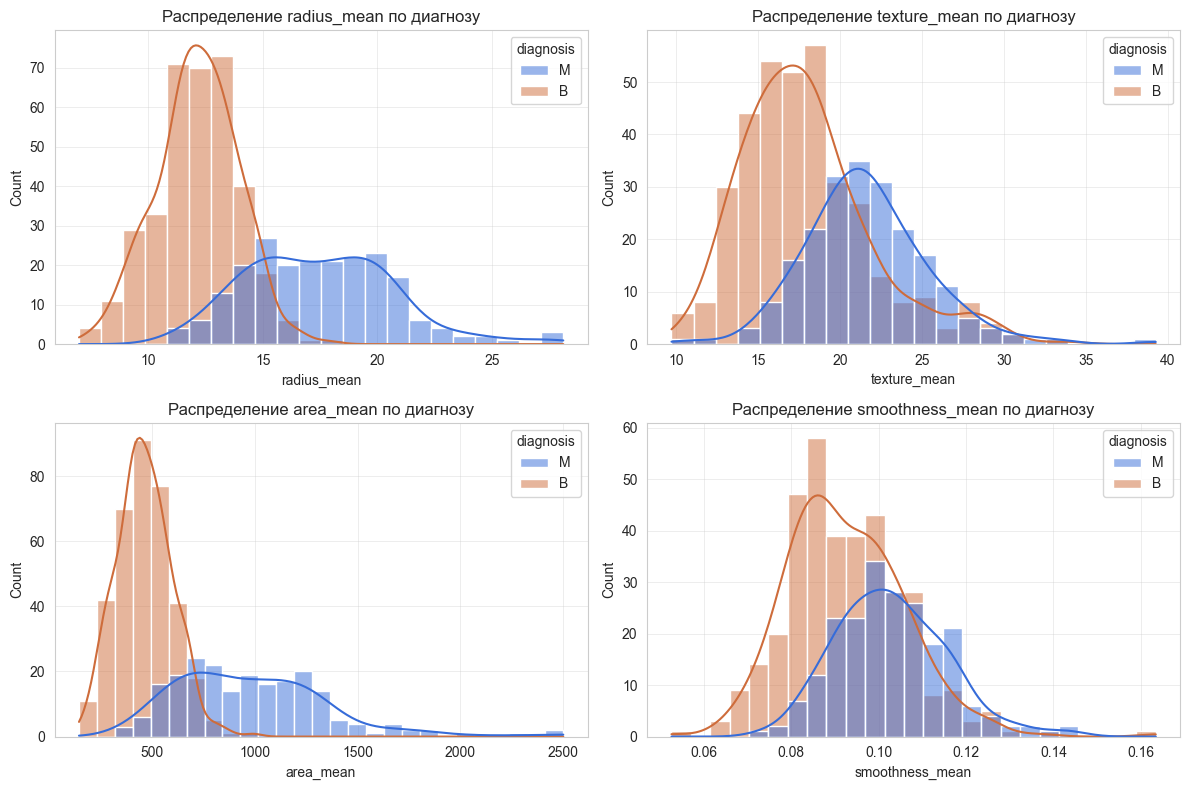

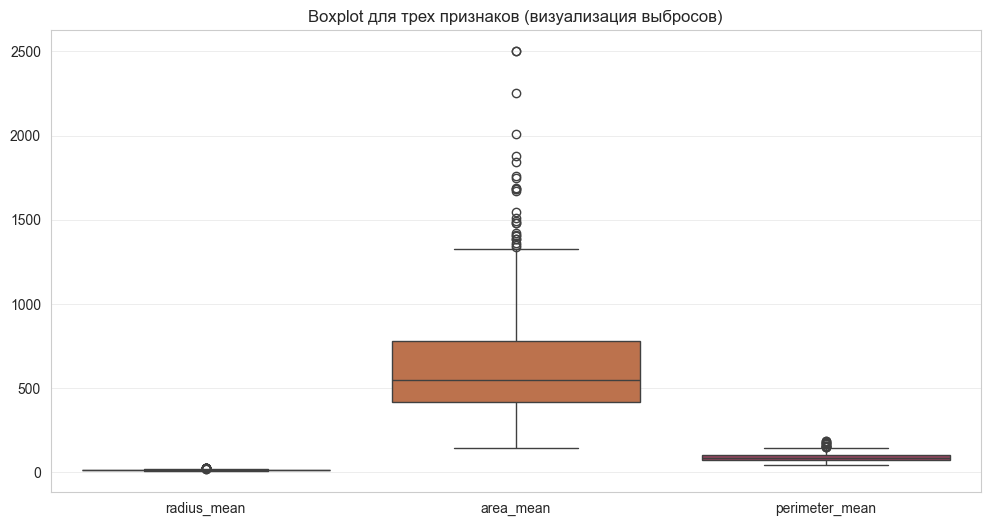

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")

# Гистограммы для 4 ключевых признаков для целевой переменной
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = ['radius_mean', 'texture_mean', 'area_mean', 'smoothness_mean']

for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Распределение {feature} по диагнозу')

plt.tight_layout()
plt.show()
# какие признаки по отношению к целевой пееменной для нашей модели буду мало информативны (то есть графики не разделяются) в нашем случае smoothness_mean для KNN и Random Forest мало информативен их можно исключить.

# Boxplot для оценки выбросов
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['radius_mean', 'area_mean', 'perimeter_mean']])
plt.title('Boxplot для трех признаков (визуализация выбросов)')
plt.show()
# для area_mean много выбросов для KNN необходимо применять масштабирование


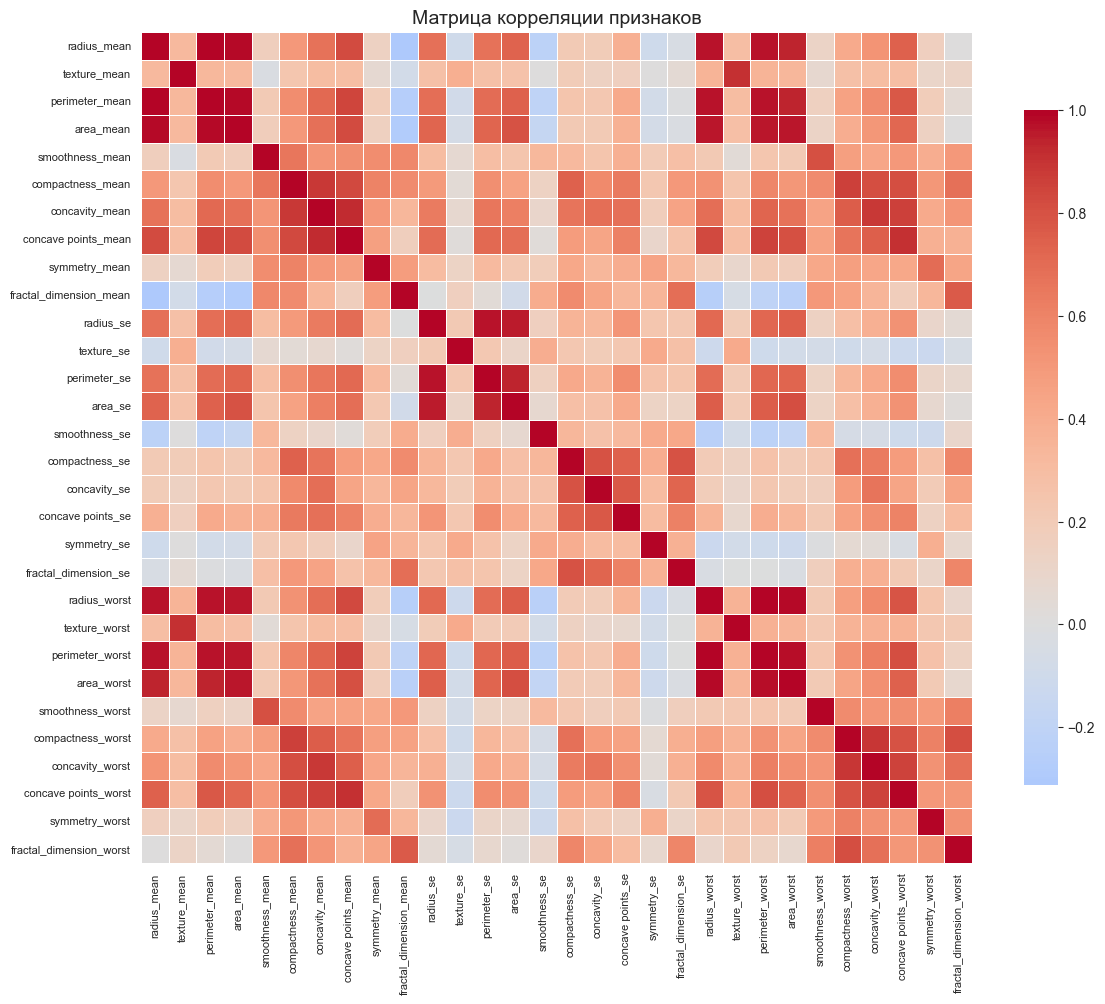

In [11]:
import numpy as np

# Исключаем целевую переменную и ID (оставляем только признаки)
X = df.drop(columns=['id', 'diagnosis'])

corr_matrix = X.corr()
plt.figure(figsize=(12, 10))  # Сделаем поменьше для читаемости

#Строим тепловую карту
sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляции признаков', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()



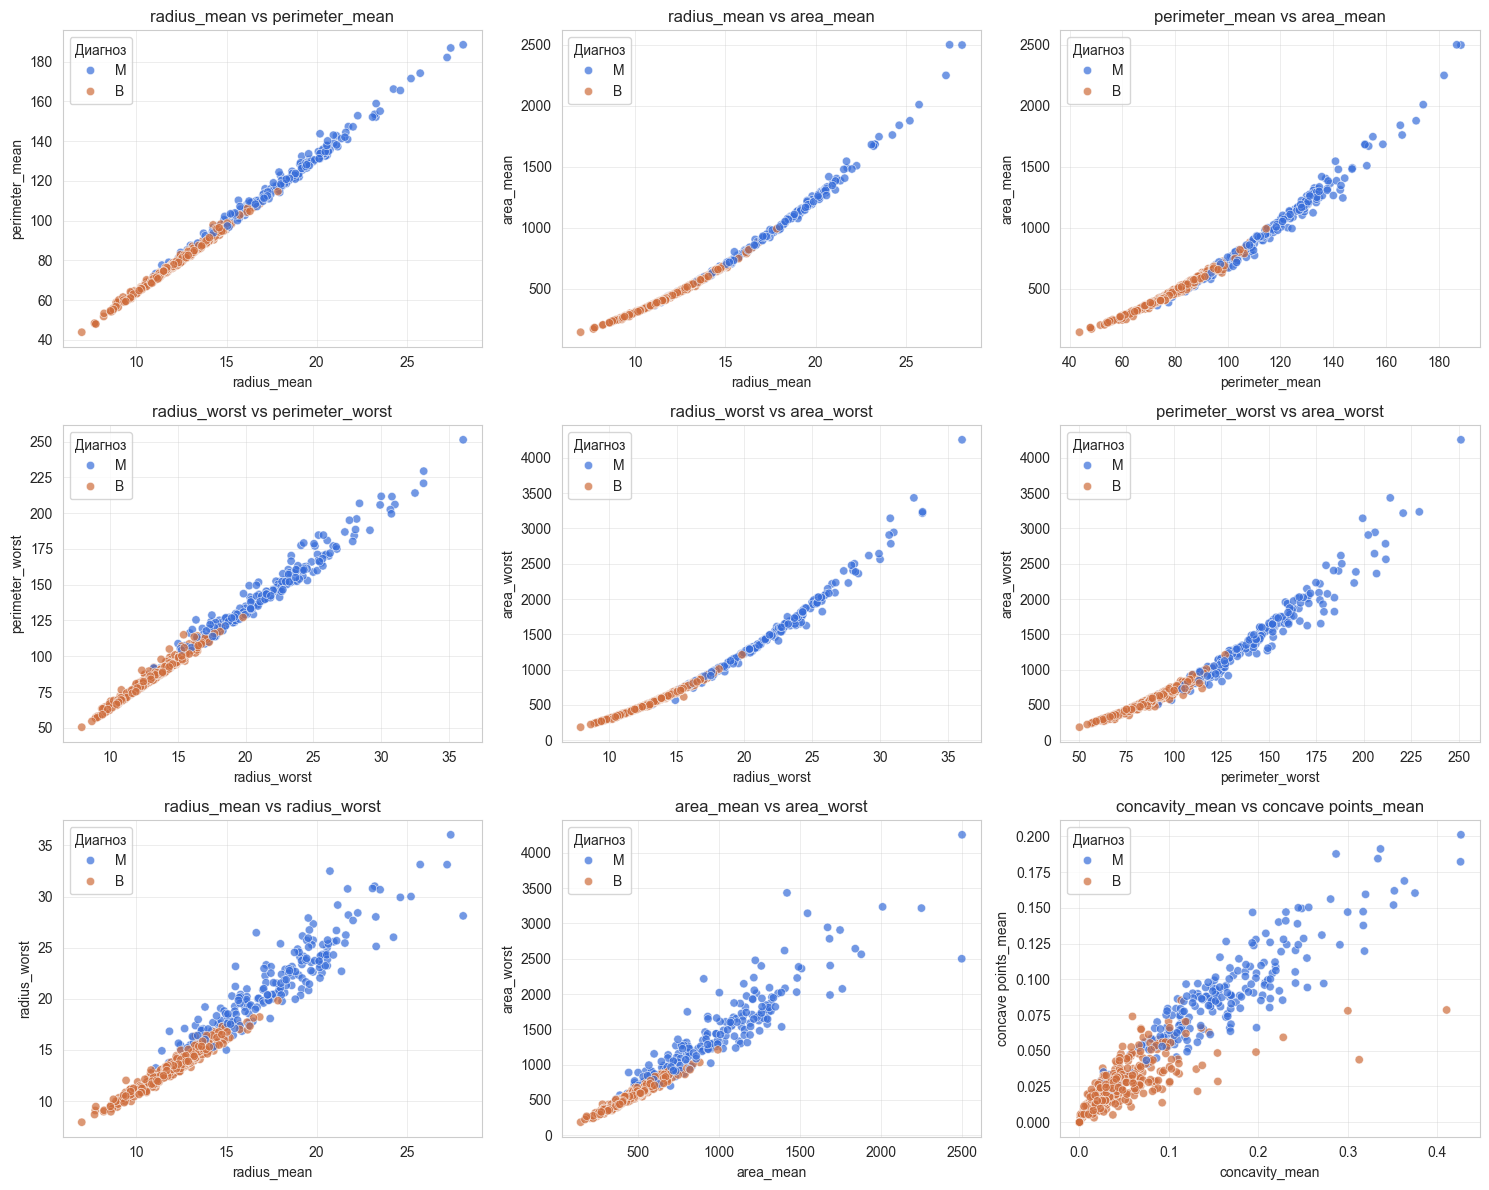

In [13]:
# Выбираем пары признаков с максимальной корреляцией

pairs = [
    ('radius_mean', 'perimeter_mean'),
    ('radius_mean', 'area_mean'),
    ('perimeter_mean', 'area_mean'),
    ('radius_worst', 'perimeter_worst'),
    ('radius_worst', 'area_worst'),
    ('perimeter_worst', 'area_worst'),
    ('radius_mean', 'radius_worst'),
    ('area_mean', 'area_worst'),
    ('concavity_mean', 'concave points_mean')
]


fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

#
for idx, (feat1, feat2) in enumerate(pairs):
    # Разделяем по диагнозу для наглядности
    sns.scatterplot(
        data=df,
        x=feat1,
        y=feat2,
        hue='diagnosis',
        alpha=0.7,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{feat1} vs {feat2}')
    axes[idx].legend(title='Диагноз')


for idx in range(len(pairs), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\Home\AppData\Local\Temp\ipykernel_16964\2165327282.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Home\AppData\Local\Temp\ipykernel_16964\2165327282.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Home\AppData\Local\Temp\ipykernel_16964\2165327282.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Home\AppData\Local\Temp\ipykernel_16964\2165327282.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

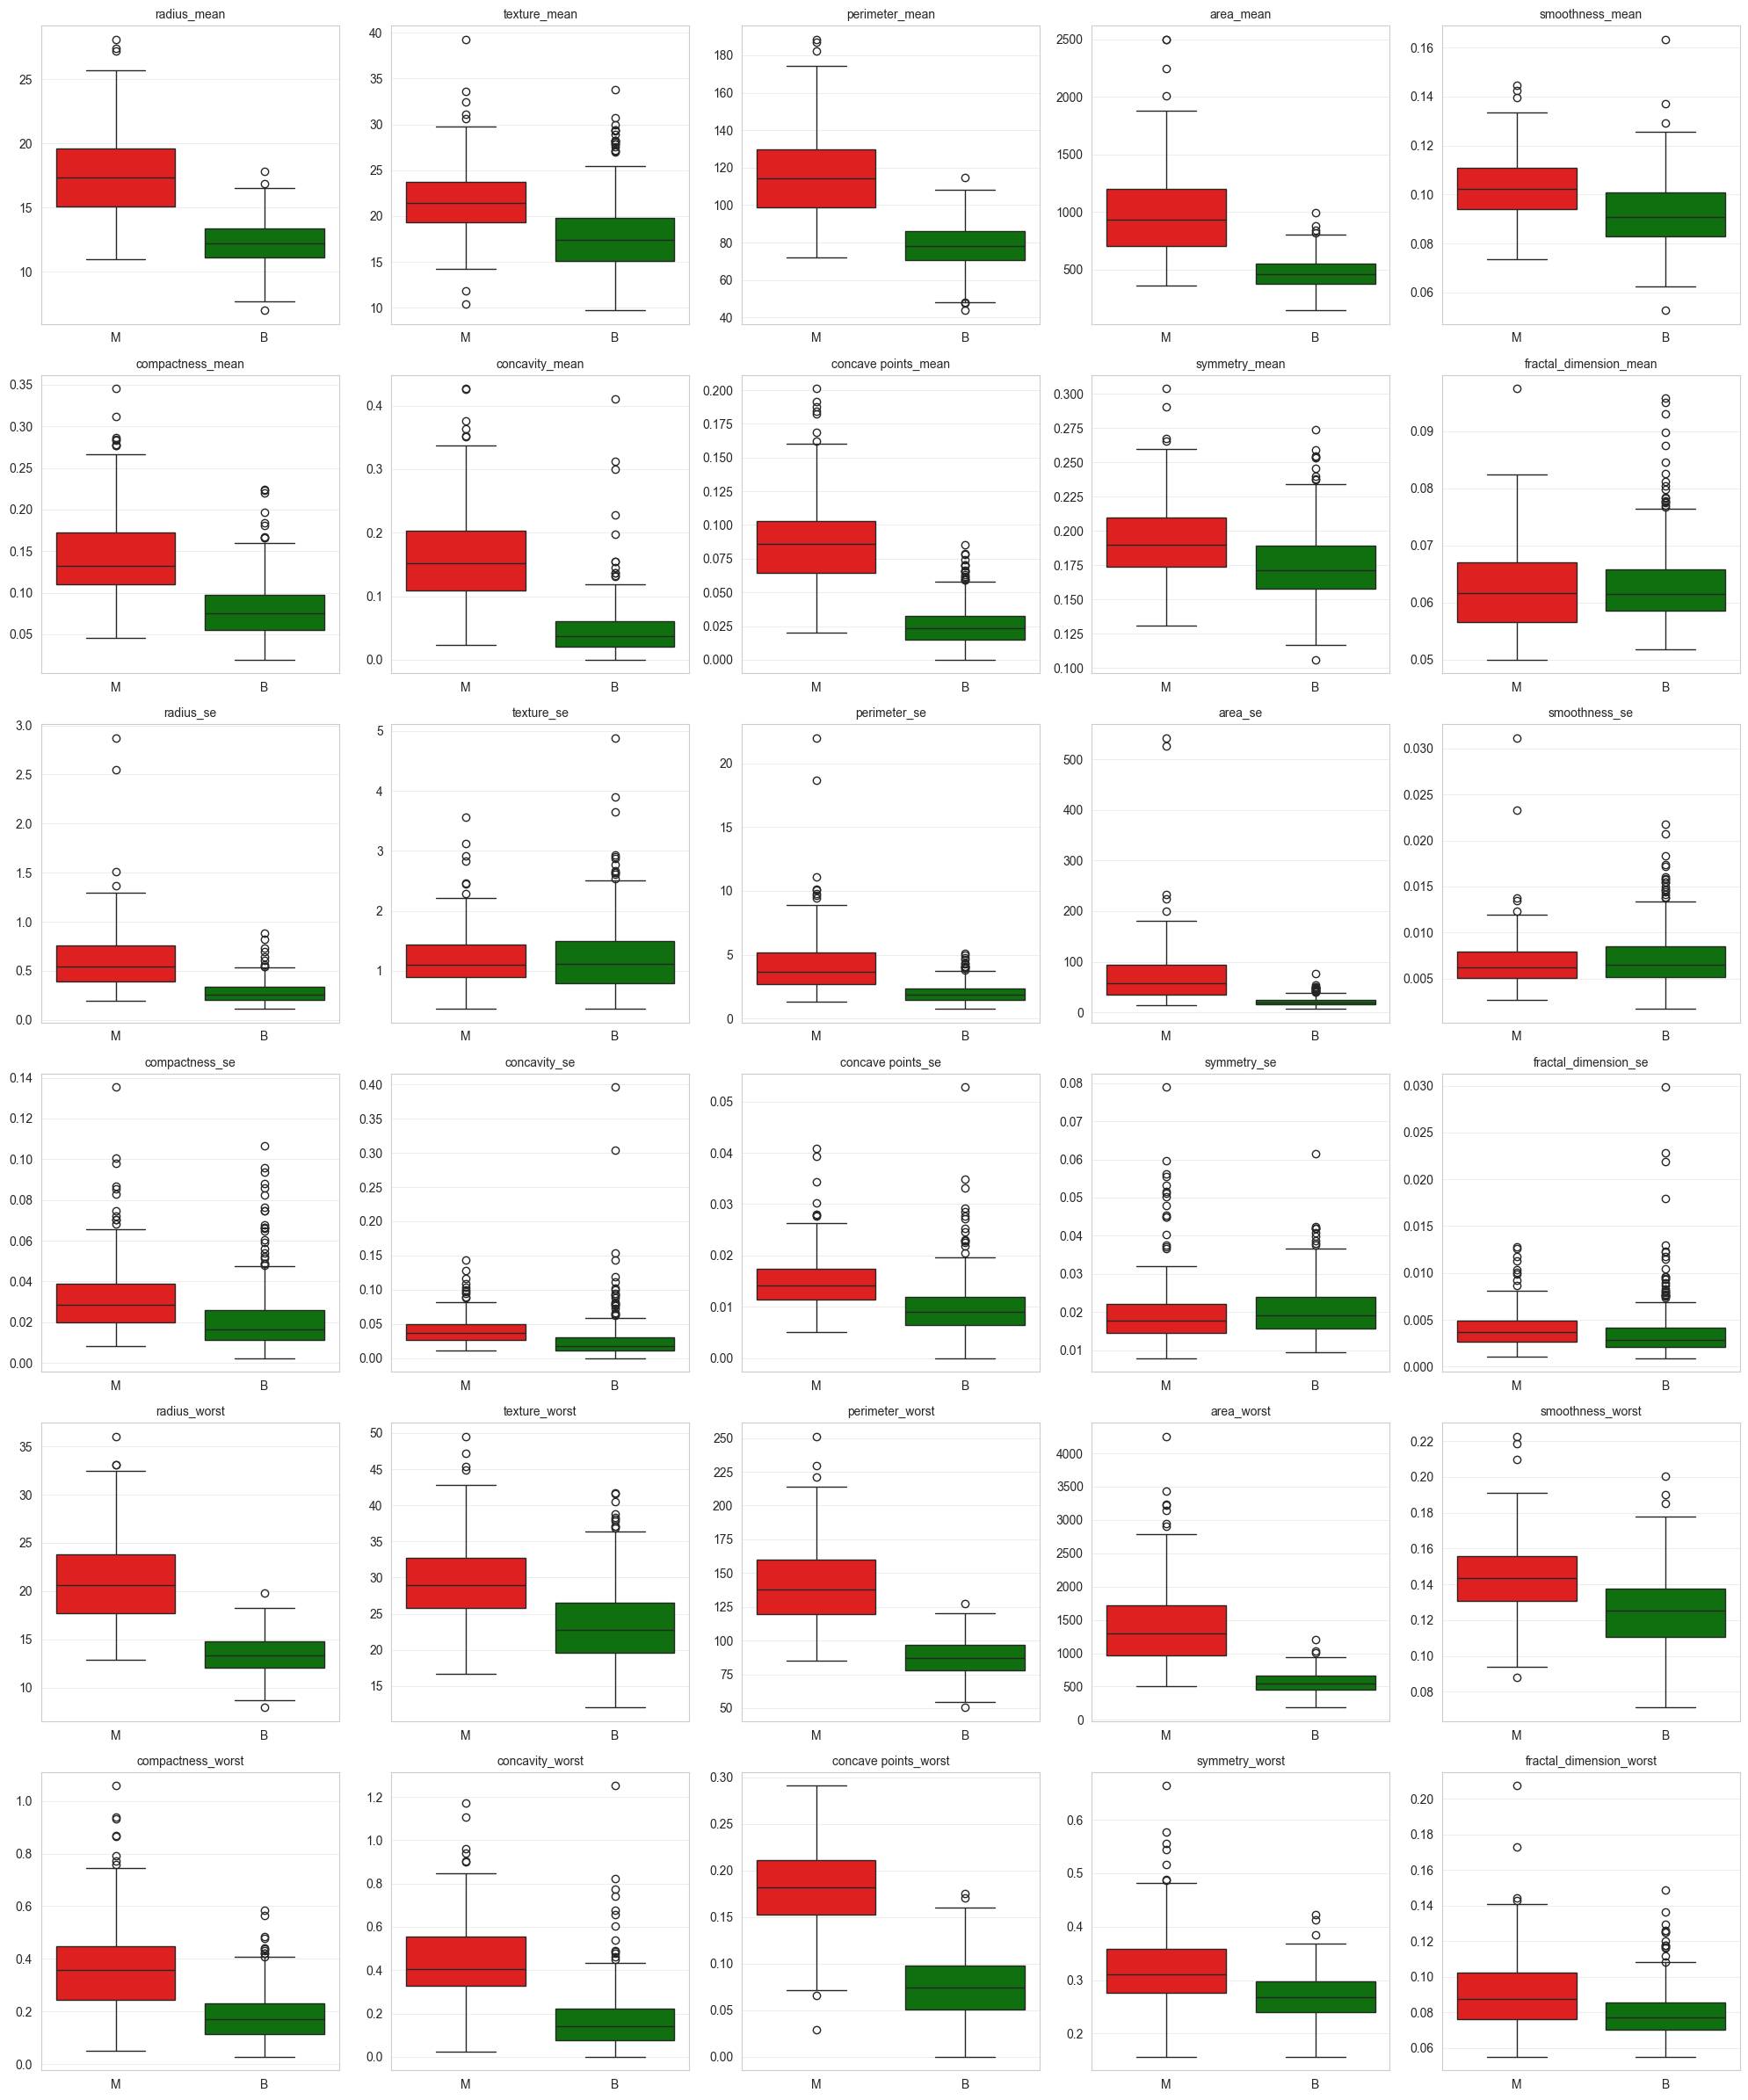

In [14]:
#Выбираем все признаки (кроме ID и диагноза)
features = df.drop(columns=['id', 'diagnosis']).columns


fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()


for idx, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='diagnosis',
        y=feature,
        ax=axes[idx],
        palette={'B': 'green', 'M': 'red'}
    )
    axes[idx].set_title(feature, fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

# 4. Убираем пустые графики (если есть)
for idx in range(len(features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [6]:
# подготовим данные только выбранне признаки и разделим на train/test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# список признаков
selected_features = [
    'area_mean', 'texture_mean', 'concave points_mean', 'symmetry_mean',
    'area_se', 'concave points_se',
    'area_worst', 'texture_worst', 'concave points_worst', 'symmetry_worst',
    'radius_mean'
]


X = df[selected_features]
y = df['diagnosis'].map({'M': 1, 'B': 0})


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Масштабирование из-за разной единицы измерений каждого признака area_mean (диапазон от сотен до тысяч) smoothness_mean (от 0 до 1). Без масштабирования модель smoothness_mean просто не воспримет
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Accuracy:  0.9532
Precision: 0.9828
Recall:    0.8906
F1-score:  0.9344


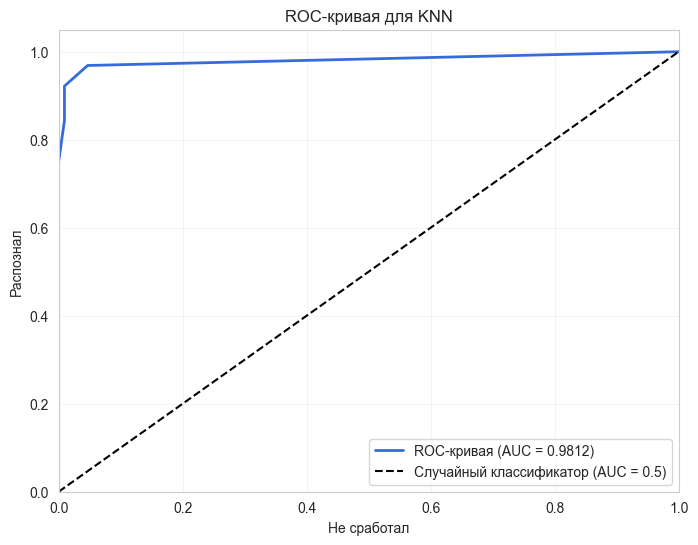


📈 Площадь под ROC-кривой (AUC): 0.9812


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score, confusion_matrix)
# KNN с параметрами по умолчанию
knn_default = KNeighborsClassifier()

#Обучаем
knn_default.fit(X_train_scaled, y_train)

#Предсказываем на тесте
y_pred = knn_default.predict(X_test_scaled)
y_pred_proba = knn_default.predict_proba(X_test_scaled)[:, 1]  # Вероятности для ROC-AUC

#Оценка
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# ROC-кривая и AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ложноотрицательных')
plt.ylabel('Злокачественный')
plt.title('ROC-кривая для KNN')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"\n📈 Площадь под ROC-кривой (AUC): {roc_auc:.4f}")

# модель довольно точная, но попробуем ее улучшить

Лучшее k по F1-score: 11
Лучшее F1-score: 0.9532


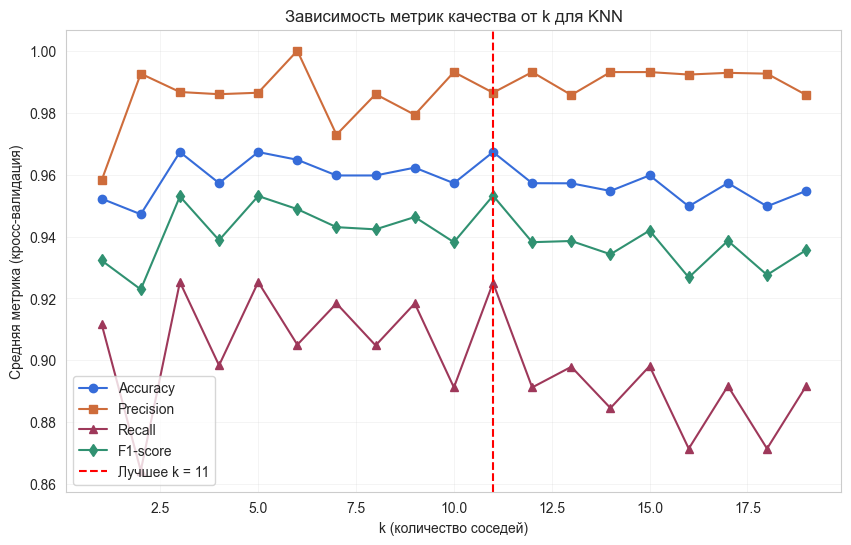

In [12]:
# для KNN подберем основной параметр k выбрать в диапазоне (1,20)
from sklearn.model_selection import cross_val_score

# диапазон
k_range = range(1, 20)

# Списки для хранения результатов
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Цикл подборки k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Кросс-валидация по 5 фолдам
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    accuracy_scores.append(scores.mean())

    # Для Precision, Recall, F1 нужна отдельная кросс-валидация
    precision_scores.append(cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='precision').mean())
    recall_scores.append(cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall').mean())
    f1_scores.append(cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1').mean())

# Находим лучшее k по F1-score (или другой метрике) F1 безопаснее с точки зрения ошибки чем Accuracy потому будем показатель брать f1-Score
best_k = k_range[np.argmax(f1_scores)]
print(f"Лучшее k по F1-score: {best_k}")
print(f"Лучшее F1-score: {max(f1_scores):.4f}")

# График зависимости метрик от k
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, label='Accuracy', marker='o')
plt.plot(k_range, precision_scores, label='Precision', marker='s')
plt.plot(k_range, recall_scores, label='Recall', marker='^')
plt.plot(k_range, f1_scores, label='F1-score', marker='d')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Лучшее k = {best_k}')
plt.xlabel('k (количество соседей)')
plt.ylabel('Средняя метрика (кросс-валидация)')
plt.title('Зависимость метрик качества от k для KNN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# k=11 получаем луший f1-score и это лучше, чем без подбора 0.9344 против 0.9532

In [13]:
# попробуем логистичеческую регрессию

#  Берём все признаки (кроме id и diagnosis)
X_all = df.drop(columns=['id', 'diagnosis'])


corr_matrix = X_all.corr().abs()


threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

# Выводим пары
print(f"Найдено {len(high_corr_pairs)} пар с корреляцией > {threshold}:")
for pair in high_corr_pairs:
    print(f"  {pair[0]} ↔ {pair[1]}: {pair[2]:.3f}")

Найдено 29 пар с корреляцией > 0.85:
  radius_mean ↔ perimeter_mean: 0.998
  radius_mean ↔ area_mean: 0.987
  radius_mean ↔ radius_worst: 0.970
  radius_mean ↔ perimeter_worst: 0.965
  radius_mean ↔ area_worst: 0.941
  texture_mean ↔ texture_worst: 0.912
  perimeter_mean ↔ area_mean: 0.987
  perimeter_mean ↔ concave points_mean: 0.851
  perimeter_mean ↔ radius_worst: 0.969
  perimeter_mean ↔ perimeter_worst: 0.970
  perimeter_mean ↔ area_worst: 0.942
  area_mean ↔ radius_worst: 0.963
  area_mean ↔ perimeter_worst: 0.959
  area_mean ↔ area_worst: 0.959
  compactness_mean ↔ concavity_mean: 0.883
  compactness_mean ↔ compactness_worst: 0.866
  concavity_mean ↔ concave points_mean: 0.921
  concavity_mean ↔ concavity_worst: 0.884
  concavity_mean ↔ concave points_worst: 0.861
  concave points_mean ↔ perimeter_worst: 0.856
  concave points_mean ↔ concave points_worst: 0.910
  radius_se ↔ perimeter_se: 0.973
  radius_se ↔ area_se: 0.952
  perimeter_se ↔ area_se: 0.938
  radius_worst ↔ perimet

In [14]:
# то что выше 85%
features_to_drop = [
    'radius_mean', 'perimeter_mean', 'area_mean',
    'radius_worst', 'perimeter_worst', 'area_worst',
    'radius_se', 'perimeter_se', 'area_se',
    'compactness_mean', 'concavity_mean', 'concave points_mean',
    'compactness_worst', 'concavity_worst', 'concave points_worst',
    'texture_mean', 'texture_worst'
]


X_reduced = df.drop(columns=['id', 'diagnosis'] + features_to_drop)

# 3. Проверяем, сколько признаков осталось
print(f"Осталось признаков: {X_reduced.shape[1]}")
print(f"Оставшиеся признаки: {list(X_reduced.columns)}")

Осталось признаков: 13
Оставшиеся признаки: ['smoothness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [18]:
# построим модель логистической регрессии
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)
# удаляем ненужные и отфильтрованные
X = df.drop(columns=['id', 'diagnosis'] + features_to_drop)
y = df['diagnosis'].map({'M': 1, 'B': 0})


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Проводим Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Модель с параметрами по умолчанию
logreg_default = LogisticRegression(random_state=42, max_iter=1000)

# Обучаем
logreg_default.fit(X_train_scaled, y_train)

# Предсказания
y_pred = logreg_default.predict(X_test_scaled)
y_pred_proba = logreg_default.predict_proba(X_test_scaled)[:, 1]

# Метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("📊 Метрики логистической регрессии (по умолчанию, после удаления коррелирующих признаков):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")



📊 Метрики логистической регрессии (по умолчанию, после удаления коррелирующих признаков):
  Accuracy:  0.9240
  Precision: 0.9180
  Recall:    0.8750
  F1-score:  0.8960


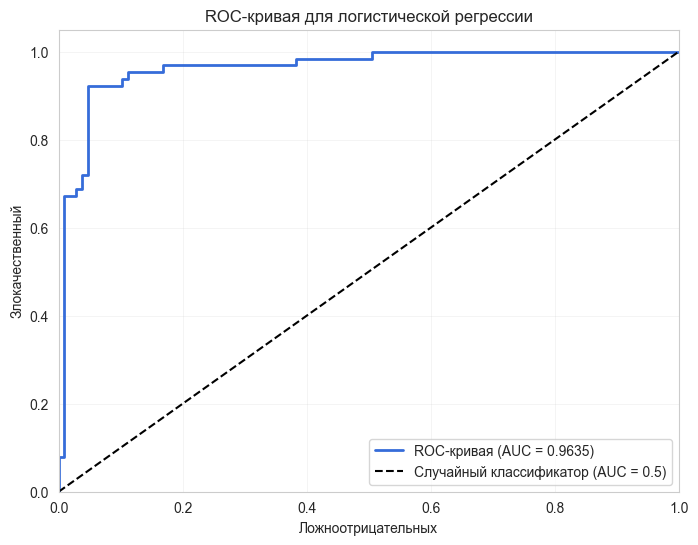


📈 Площадь под ROC-кривой (AUC): 0.9635


In [19]:
# ROC кривая
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ложноотрицательных')
plt.ylabel('Злокачественный')
plt.title('ROC-кривая для логистической регрессии')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
print(f"\n📈 Площадь под ROC-кривой (AUC): {roc_auc:.4f}")


📌 Важность признаков (коэффициенты логистической регрессии):
                Признак  Коэффициент  abs_коэф
 fractal_dimension_mean    -2.949192  2.949192
      concave points_se     1.920169  1.920169
fractal_dimension_worst     1.378818  1.378818
        smoothness_mean     1.262202  1.262202
         symmetry_worst     1.218010  1.218010
       smoothness_worst     0.760875  0.760875
             texture_se     0.705524  0.705524
          smoothness_se    -0.627470  0.627470
            symmetry_se    -0.538778  0.538778
   fractal_dimension_se    -0.519357  0.519357
         compactness_se     0.478504  0.478504
          symmetry_mean    -0.172931  0.172931
           concavity_se    -0.172833  0.172833


C:\Users\Home\AppData\Local\Temp\ipykernel_16912\3770058732.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette=colors)


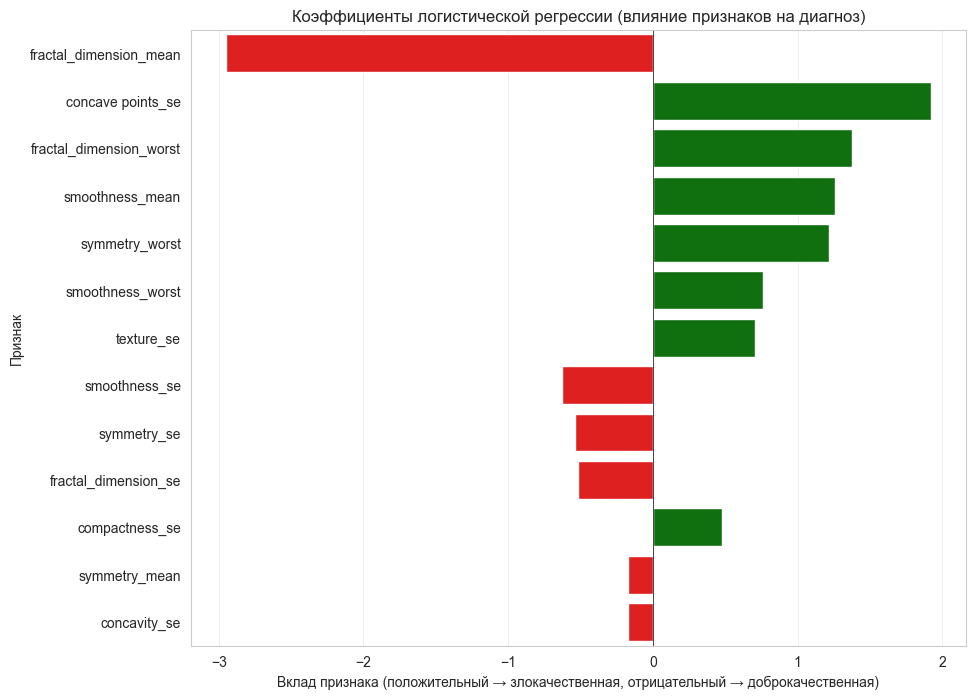

In [20]:
# Получаем коэффициенты
coefs = logreg_default.coef_[0]
feature_names = X.columns

# Создаём DataFrame для наглядности
coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefs,
    'abs_коэф': np.abs(coefs)
})
coef_df = coef_df.sort_values('abs_коэф', ascending=False)

print("\n📌 Важность признаков (коэффициенты логистической регрессии):")
print(coef_df.to_string(index=False))

# 3. Визуализация коэффициентов
plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'green' for c in coef_df['Коэффициент']]
sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Коэффициенты логистической регрессии (влияние признаков на диагноз)')
plt.xlabel('Вклад признака (положительный → злокачественная, отрицательный → доброкачественная)')
plt.show()
# отрицательные уменьшают риск положительные увеличивают

In [22]:
# Модель с автоматическим подбором C (5-кратная кросс-валидация) снова ориентируется на f1-score
from sklearn.linear_model import LogisticRegressionCV

logreg_cv = LogisticRegressionCV(
    Cs=10,
    cv=5,
    scoring='f1',
    random_state=42,
    max_iter=1000
)

# Обучаем
logreg_cv.fit(X_train_scaled, y_train)

# Смотрим, какое C выбрано
print(f"Лучшее C: {logreg_cv.C_[0]:.4f}")

# результат 2.7826 выше единицы - слабая регуляризация

E:\Projects\Python\MashineLeaning\HomeWork1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
E:\Projects\Python\MashineLeaning\HomeWork1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Лучшее C: 2.7826


In [23]:
# снова оценим все метрики

y_pred = logreg_cv.predict(X_test_scaled)

# Считаем метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Метрики на тестовой выборке:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

Метрики на тестовой выборке:
  Accuracy:  0.9240
  Precision: 0.9180
  Recall:    0.8750
  F1-score:  0.8960


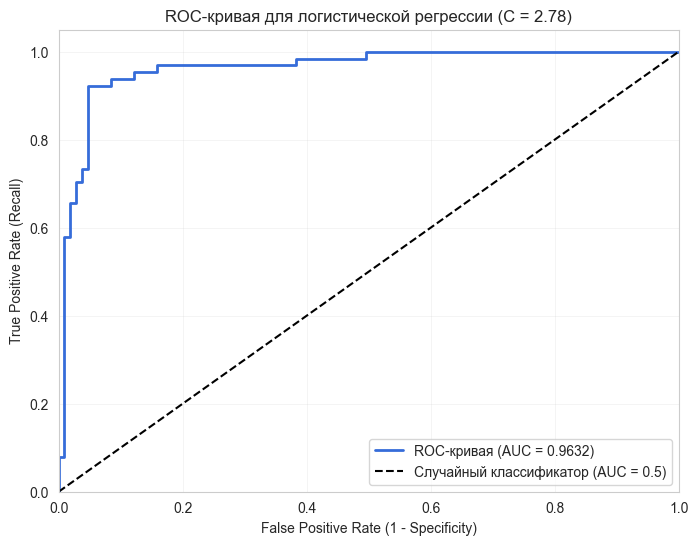


📈 Площадь под ROC-кривой (AUC): 0.9632


In [24]:
# ROC кривая
y_pred_proba = logreg_cv.predict_proba(X_test_scaled)[:, 1]

# Считаем AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)


# Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-кривая для логистической регрессии (C = 2.78)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"\n📈 Площадь под ROC-кривой (AUC): {roc_auc:.4f}")
# что из коробки что с настройкой параметров разницы нет даже хуже


                Признак  Коэффициент  abs_коэф
 fractal_dimension_mean    -3.592327  3.592327
      concave points_se     2.210504  2.210504
fractal_dimension_worst     1.893959  1.893959
        smoothness_mean     1.614043  1.614043
         symmetry_worst     1.373021  1.373021
             texture_se     0.849758  0.849758
   fractal_dimension_se    -0.686046  0.686046
          smoothness_se    -0.654265  0.654265
       smoothness_worst     0.624051  0.624051
            symmetry_se    -0.548103  0.548103
         compactness_se     0.444852  0.444852
          symmetry_mean    -0.254879  0.254879
           concavity_se    -0.190962  0.190962


C:\Users\Home\AppData\Local\Temp\ipykernel_16912\464971637.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette=colors)


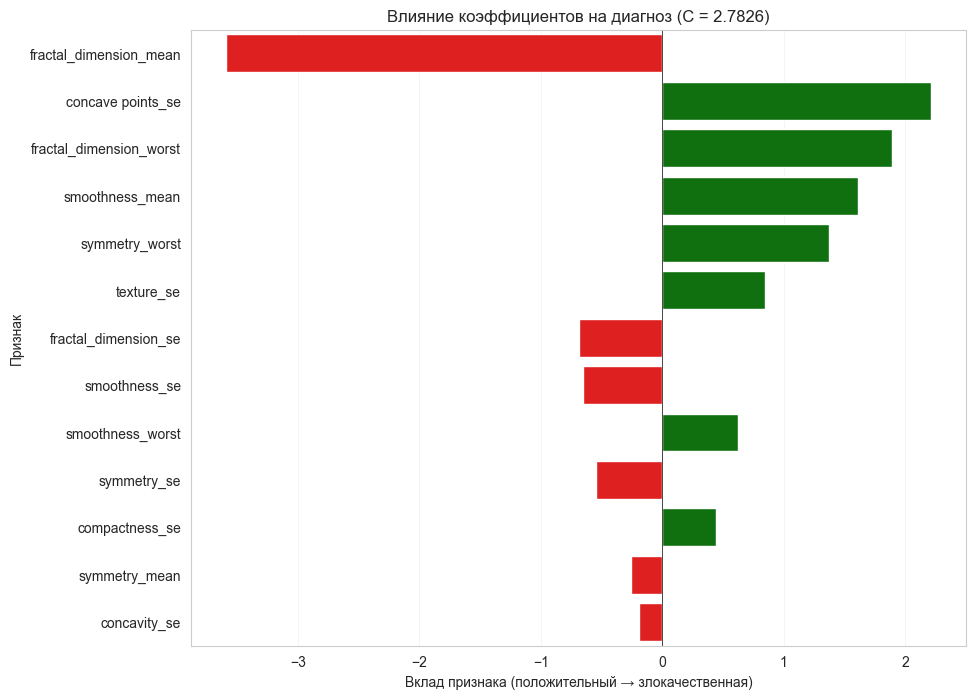

In [26]:
# матрица коэффициентов влиянию на целевую переменную

coefs = logreg_cv.coef_[0]
feature_names = X.columns

# Создаём DataFrame для сортировки
coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefs,
    'abs_коэф': np.abs(coefs)
}).sort_values('abs_коэф', ascending=False)

print(coef_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'green' for c in coef_df['Коэффициент']]
sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.title(f'Влияние коэффициентов на диагноз (C = {logreg_cv.C_[0]:.4f})')
plt.xlabel('Вклад признака (положительный → злокачественная)')
plt.ylabel('Признак')
plt.grid(axis='x', alpha=0.3)
plt.show()

# Итоговый вывод о главному показателю для определения болезни f1-score много лучше у KNN. по этому для задачи определения (или даже так сказать не ошибки - лучше перебдеть чем недобдеть) я бы выбрал KNN